<a href="https://colab.research.google.com/github/kush067/25BDS0156-KUSHALAGARWAL/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
# The URL "https://githubusercontent.com" is incomplete and causing an error.
# Please replace it with a direct link to a raw CSV file, for example:
# url = "https://raw.githubusercontent.com/username/repository/branch/path/to/your/file.csv"
url = "https://githubusercontent.com"
df = pd.read_csv(url)

# Display initial information
print("--- FIRST 3 ROWS ---")
print(df.head(3))
print("\n--- DATA TYPES ---")
print(df.dtypes)

URLError: <urlopen error [Errno -5] No address associated with hostname>

In [2]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

# Dynamically upload the file from your local machine
uploaded = files.upload()

# Automatically fetch the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the CSV dataset dynamically without hardcoding data
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"\n Successfully loaded: {file_name}")
print("--- FIRST 3 ROWS ---")
print(df.head(3))


Saving WineQT.csv to WineQT.csv

 Successfully loaded: WineQT.csv
--- FIRST 3 ROWS ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  


--- SUMMARY STATISTICS ---
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000   

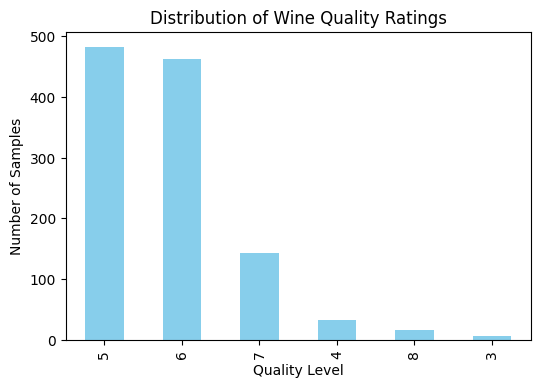

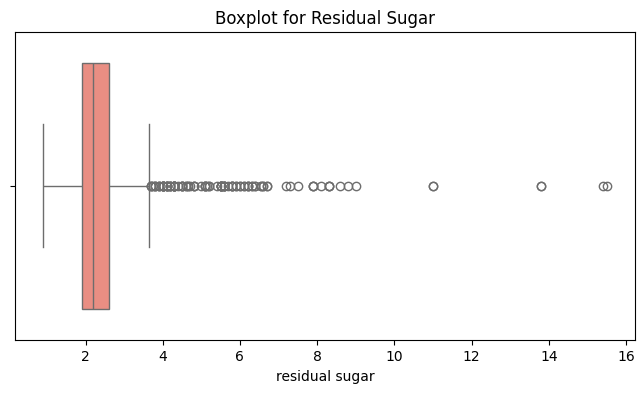

In [3]:
# 1. Summary descriptive statistics for column properties
print("--- SUMMARY STATISTICS ---")
print(df.describe())

# 2. Central tendencies of a target variable (e.g., pH)
print("\n--- pH COLUMN CENTRAL TENDENCY ---")
print("Mean:   ", df["pH"].mean())
print("Median: ", df["pH"].median())
print("Mode:\n", df["pH"].mode())

# 3. Bar Chart: Check frequency distribution of your quality ratings
plt.figure(figsize=(6, 4))
df['quality'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Wine Quality Ratings")
plt.ylabel('Number of Samples')
plt.xlabel('Quality Level')
plt.show()

# 4. Boxplot: Discover extreme value outliers in your columns
plt.figure(figsize=(8, 4))
sns.boxplot(x="residual sugar", data=df, color='salmon')
plt.title("Boxplot for Residual Sugar")
plt.show()


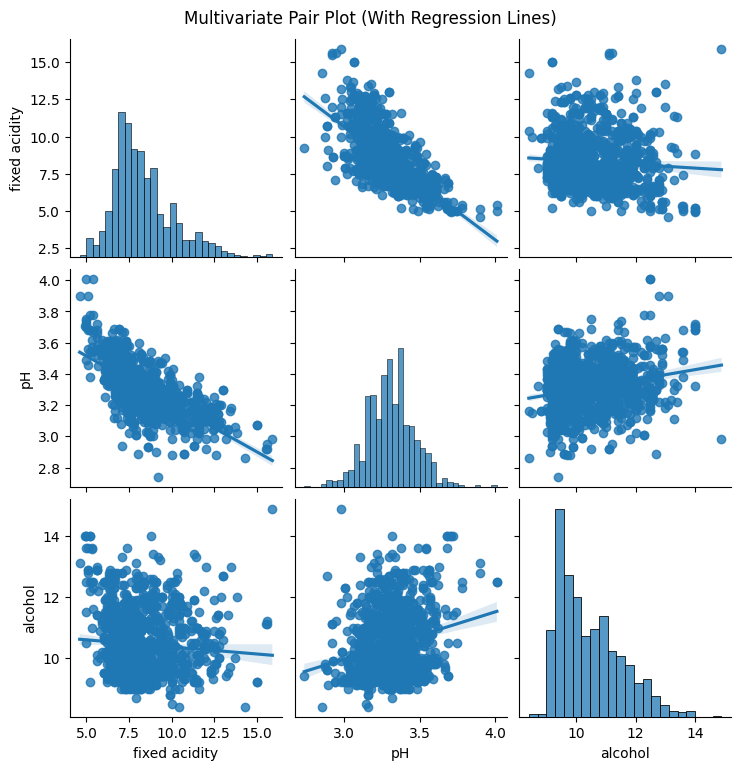

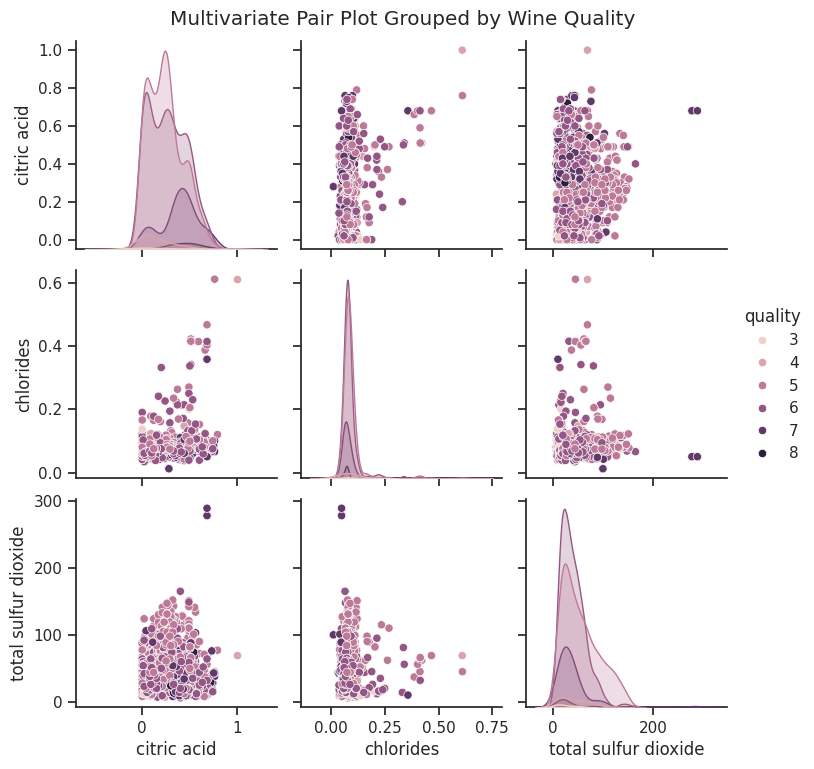

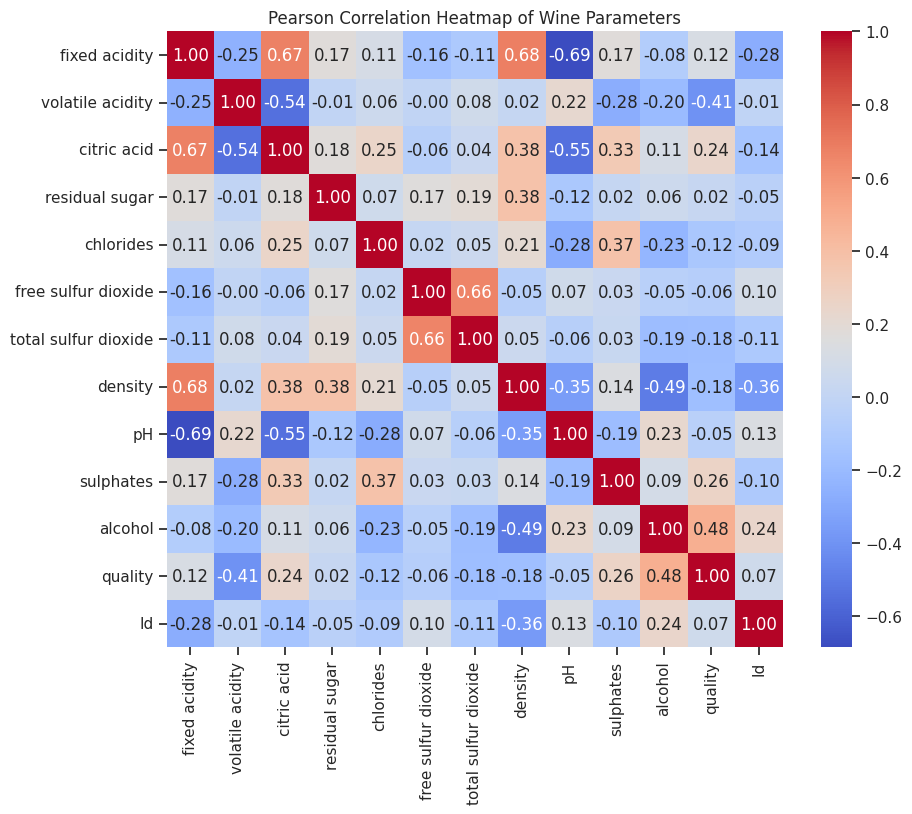

In [4]:
# 1. Matrix Scatter Plot (Pair Plot) with Regression trends
# Visualizes multiple fields at once to locate multi-variable dependencies
sns.pairplot(df, vars=['fixed acidity', 'pH', 'alcohol'], kind="reg")
plt.suptitle("Multivariate Pair Plot (With Regression Lines)", y=1.02)
plt.show()

# 2. Pair Plot Grouped by Categorical Hue
sns.set(style="ticks")
sns.pairplot(df, height=2.5, vars=['citric acid', 'chlorides', 'total sulfur dioxide'], hue="quality")
plt.suptitle("Multivariate Pair Plot Grouped by Wine Quality", y=1.02)
plt.show()

# 3. Generate Pearson Correlation Matrix for numeric features
correlation_matrix = df.corr(method='pearson')

# 4. Visualization: Correlation Map Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, xticklabels=correlation_matrix.columns, yticklabels=correlation_matrix.columns, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Pearson Correlation Heatmap of Wine Parameters")
plt.show()


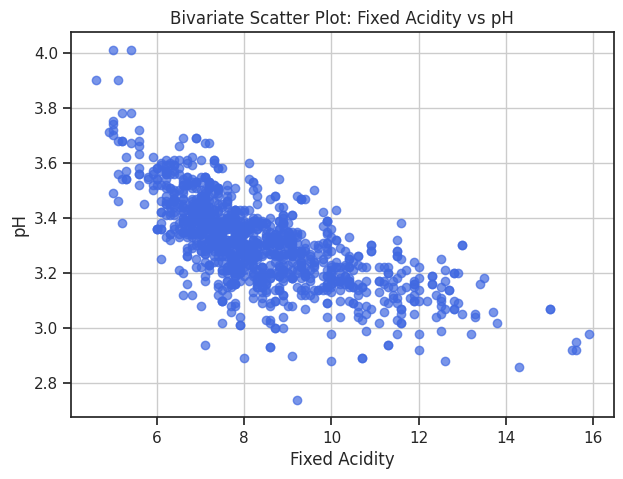

/tmp/ipykernel_511/3364583727.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y="alcohol", data=df, palette="Set2")


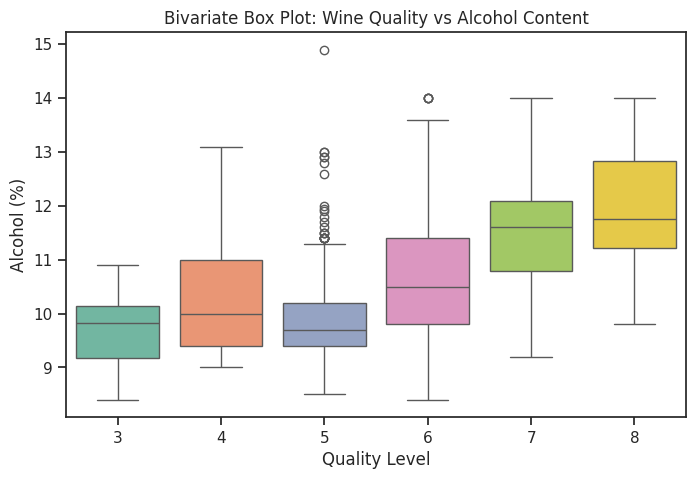

/tmp/ipykernel_511/3364583727.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y="volatile acidity", data=df, palette="coolwarm")


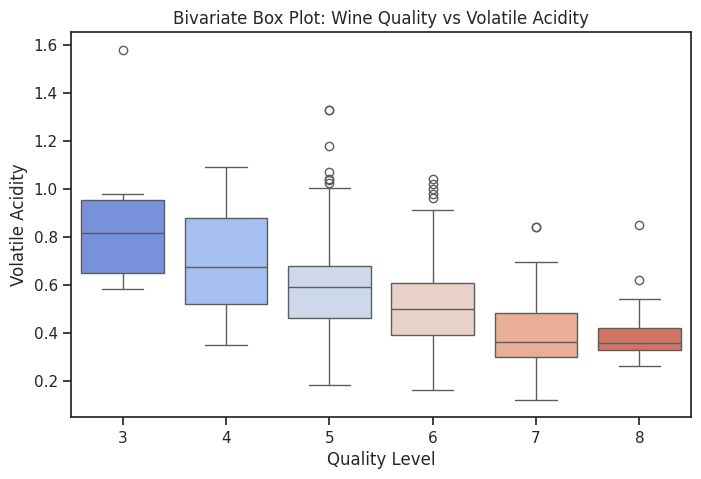

In [5]:
# ==========================================
# BIVARIATE ANALYSIS (Two Variables)
# ==========================================

# 1. Scatter Plot: Continuous vs Continuous (e.g., Fixed Acidity vs pH)
# This mimics the horsepower vs price scatter plot on page 13 & 14
plt.figure(figsize=(7, 5))
plt.scatter(df["fixed acidity"], df["pH"], color="royalblue", alpha=0.7)
plt.title("Bivariate Scatter Plot: Fixed Acidity vs pH")
plt.xlabel("Fixed Acidity")
plt.ylabel("pH")
plt.grid(True)
plt.show()

# 2. Box Plot: Categorical vs Continuous (e.g., Quality Level vs Alcohol)
# This mimics the engine location vs price boxplot on page 14 & 15
plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=df, palette="Set2")
plt.title("Bivariate Box Plot: Wine Quality vs Alcohol Content")
plt.xlabel("Quality Level")
plt.ylabel("Alcohol (%)")
plt.show()

# 3. Box Plot: Categorical vs Continuous Alternative (e.g., Quality Level vs Volatile Acidity)
plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="volatile acidity", data=df, palette="coolwarm")
plt.title("Bivariate Box Plot: Wine Quality vs Volatile Acidity")
plt.xlabel("Quality Level")
plt.ylabel("Volatile Acidity")
plt.show()
